In [40]:
#Exercico 2

#Passo 1: gerando a Binomial pelo método ingênuo
n = 100
import numpy as np
uniforme = np.random.uniform(size=n) 

p = .5
M = 1000
amostra = []

for i in range(M):
    uniforme = np.random.uniform(size=n)
    binomial = np.sum(uniforme <= p) 
    amostra.append(binomial) 


In [41]:
#Passo 2: implementando o método recursivo

def Binomial_recursiva(n,p):
    U = np.random.uniform(0,1)
    i = 0
    p_i = (1-p)**n
    F = p_i
        
    while U > F:
        p_i = ((n-i)/(i+1)) * (p/(1-p)) * p_i
        i = i + 1
        F = F + p_i
    
    return i

def bin_recursiva_amostra(n,p,M):
    amostra = []
    for j in range(M):
        resultado = Binomial_recursiva(n,p)
        amostra.append(resultado)
    
    return amostra
    
print(bin_recursiva_amostra(n=10,p=0.5,M=100))

[4, 3, 3, 6, 4, 5, 5, 7, 2, 6, 5, 4, 7, 7, 8, 3, 7, 6, 3, 7, 5, 6, 4, 4, 3, 6, 5, 6, 3, 6, 4, 6, 5, 5, 3, 7, 6, 5, 4, 5, 5, 4, 4, 7, 5, 2, 7, 6, 6, 4, 6, 2, 9, 4, 7, 5, 7, 5, 7, 7, 6, 4, 4, 6, 6, 4, 5, 7, 5, 3, 5, 7, 7, 2, 3, 5, 7, 3, 5, 6, 7, 3, 5, 7, 6, 3, 6, 4, 2, 5, 4, 2, 4, 4, 5, 6, 6, 4, 4, 3]


In [57]:
#Passo 3: gerando valores para p e n

import time as time

valores_n = np.linspace(1,100,4).astype(int)
valores_p = np.linspace(0.3,0.8,4)

amostra_ingenua = []
amostra_recursiva = []
media_tempo_ingenua = []
media_tempo_recursiva = []

M = 100

for n in valores_n:
    for p in valores_p:
        tempo_ingenuo = []
        for j in range(M):
            inicio = time.time()
            for i in range(M):
                 uniforme = np.random.uniform(size=n)
                 binomial = np.sum(uniforme <= p) 
                 amostra_ingenua.append(binomial)
            fim = time.time()
            tempo_ingenuo.append(fim-inicio)
        tempo_recursivo = []
        for j in range(M):
            inicio = time.time()
            resultado = bin_recursiva_amostra(n,p,M)
            amostra_recursiva.append(resultado)
            fim = time.time()
            tempo_recursivo.append(fim-inicio)

        media_tempo_ingenua.append(np.mean(tempo_ingenuo))
        media_tempo_recursiva.append(np.mean(tempo_recursivo))
    

print(f"media ingenua: {media_tempo_ingenua},\n media recursiva: {media_tempo_recursiva}")
        

media ingenua: [np.float64(0.0016000008583068848), np.float64(0.0012200021743774415), np.float64(0.0012900018692016601), np.float64(0.0011899971961975098), np.float64(0.001419999599456787), np.float64(0.0012900018692016601), np.float64(0.0013300037384033202), np.float64(0.0014700007438659668), np.float64(0.0016399979591369628), np.float64(0.001380000114440918), np.float64(0.0015200018882751466), np.float64(0.0015000033378601075), np.float64(0.0014600014686584472), np.float64(0.001529998779296875), np.float64(0.0015000009536743164), np.float64(0.0015999984741210938)],
 media recursiva: [np.float64(0.0004899978637695312), np.float64(0.0004999995231628418), np.float64(0.000539999008178711), np.float64(0.0005500006675720215), np.float64(0.0015100002288818359), np.float64(0.0019099974632263183), np.float64(0.0027900004386901857), np.float64(0.003540000915527344), np.float64(0.002309999465942383), np.float64(0.003710000514984131), np.float64(0.004899997711181641), np.float64(0.00556999444961

<function matplotlib.pyplot.show(close=None, block=None)>

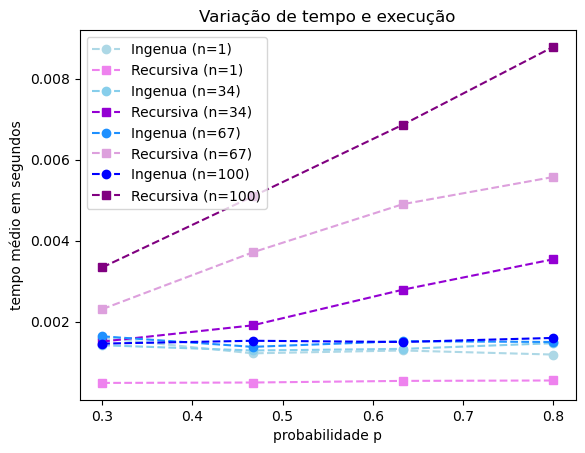

In [61]:
#Passo 4: gerando os gráficos comparativos

import pandas as pd
import matplotlib.pyplot as plt

cores_ing = ["lightblue", "skyblue",  "dodgerblue", "blue"]
cores_rec = ["violet", "darkviolet", "plum", "purple"]

for i in range(len(valores_n)):
    n = valores_n[i]
    inicio = i * 4
    fim = inicio + 4
    tempos_ing = media_tempo_ingenua[inicio:fim]
    tempos_rec = media_tempo_recursiva[inicio:fim]
    plt.plot(valores_p, tempos_ing, marker = "o", linestyle = "--", color = cores_ing[i],
    label = f"Ingenua (n={n})")
    plt.plot(valores_p, tempos_rec, marker = "s", linestyle = "--", color = cores_rec[i],
    label = f"Recursiva (n={n})")

plt.title("Variação de tempo e execução")
plt.xlabel("probabilidade p")
plt.ylabel("tempo médio em segundos")
plt.legend(loc="best")
plt.show
    

In [ ]:
#o método ingênuo apresenta maior rapidez quando n é fixo e é mais lento com o aumento de n.
#Já o método recursivo apresenta uma demora maior a medida que n e p crescem
